In [121]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import random
import time
from myfunctions import *
import warnings
warnings.filterwarnings("ignore")

In [2]:
def get_sqdist(vec1, vec2):
    
    length = len(vec1)
    assert(len(vec2)==length)
    sum_sq = 0
    for i in range(length):
        sum_sq += (vec1[i]-vec2[i])**2
    return sum_sq

def get_shape_reps(shapes_reps, subset):
    
    subset_reps = []
    for i in subset:
        subset_reps.append(shapes_reps[i])
    return subset_reps


def get_dist_nn_ml(best_subset_reps, node_rep):
    
    '''This function returns the smallest distance of the query node with the best subset'''
    least_dist = 100000000
    for i in range(len(best_subset_reps)):
        dist = get_sqdist(node_rep, best_subset_reps[i])
        if(dist < least_dist):
            least_dist = dist
    return least_dist

def get_dist_knn_ml(knn, best_subset_reps, node_rep):
    
    '''This function returns the avg of the K smallest distance of the query node with the best subset'''
    if(knn < 1 or knn > len(best_subset_reps)):
        print("Choose an appropriate K-NN value -> [1, number of nodes in best subset]")
        return -1
    
    least_dist = []
    for i in range(len(best_subset_reps)):
        least_dist.append(get_sqdist(node_rep, best_subset_reps[i]))
    least_dist = np.sort(np.array(least_dist))
    least_distance = np.sum(least_dist[:knn])/knn
    return least_distance

In [3]:
def get_best_subset_in_other(knn, roots, subchildren, shape_reps, best_subset_reps, print_flag):
    
    nodes = range(np.sort(np.array(list(subchildren.keys())))[-1]+1)
    nodes_reps = get_shape_reps(shape_reps, nodes)
    
    dist_vec = []
    for node_rep in nodes_reps:
        
        if(knn == 1):
            dist_vec.append(get_dist_nn_ml(best_subset_reps, node_rep))
        else:
            dist_vec.append(get_dist_knn_ml(knn, best_subset_reps, node_rep))
    
    
    cur_best_subset = []
    
    if(print_flag): print("ROOTS:", roots)
    
    for root in roots:
        
        children = subchildren[root]
        
        if(print_flag): print("\n")
        if(print_flag): print("NEW ROOT:", root, children)
        
        best_score = dist_vec[root]
        best_subset = [root]
        
        if(print_flag): print("STARTING:", best_score, best_subset)
        
        for child in children:
            sum_child = 0.0
            for i in range(len(child)):
                cur_score = dist_vec[child[i]]
                sum_child += cur_score
            sum_child /= len(child)
            
            if(print_flag): print("ITERATION:", child, sum_child)
            
            if(sum_child < best_score):
                best_score = sum_child
                best_subset = list(child)
                if(print_flag): print("BEST UPDATED:", best_score, best_subset)
                
        for node in best_subset:
            cur_best_subset.append(node)
    
    if(print_flag): print("\nCUR BEST SUBSET:", cur_best_subset)
    return cur_best_subset

## Testing

In [4]:
import json

with open('tree_p7.json') as json_file:
    tree_p7 = json.load(json_file)
with open('tree_p8.json') as json_file:
    tree_p8 = json.load(json_file)
with open('tree_p24.json') as json_file:
    tree_p24 = json.load(json_file)
with open('tree_p34.json') as json_file:
    tree_p34 = json.load(json_file)
with open('tree_p46.json') as json_file:
    tree_p46 = json.load(json_file)
with open('tree_p52.json') as json_file:
    tree_p52 = json.load(json_file)
    
tree_p7 = get_corrected_dict(tree_p7)
tree_p8 = get_corrected_dict(tree_p8)
tree_p24 = get_corrected_dict(tree_p24)
tree_p34 = get_corrected_dict(tree_p34)
tree_p46 = get_corrected_dict(tree_p46)
tree_p52 = get_corrected_dict(tree_p52)

## All dimensions

In [5]:
roots_p7 = get_roots(tree_p7)
subchildren_p7 = get_complete_children_sets(tree_p7)
best_p7 = [245, 159, 158, 191, 193, 63, 125, 123, 186, 54, 52, 238, 239, 68, 163, 65, 194, 167, 164, 148, 208, 145, 205, 84, 83, 212, 178, 45, 228, 229, 201, 171, 170, 34, 137, 200, 109, 188]
shapes_reps_p7 = np.load("p7_ShapeReps_246x6144.npy")
# shapes_dist_p7 = np.load("p7_ShapeDist_6144_Euc.npy")
best_shapes_p7 = get_shape_reps(shapes_reps_p7, best_p7)

roots_p8 = get_roots(tree_p8)
subchildren_p8 = get_complete_children_sets(tree_p8)
best_p8 = [45, 116, 112, 111, 75, 232, 233, 180, 236, 43, 231, 201, 228, 107, 229, 47, 48, 51, 122, 152, 119, 243, 89, 55, 56, 128, 159, 158, 161, 162, 134, 135, 226, 199, 222, 195, 224, 132, 104]
shapes_reps_p8 = np.load("p8_ShapeReps_252x6144.npy")
# shapes_dist_p8 = np.load("p8_ShapeDist_6144_Euc.npy")
best_shapes_p8 = get_shape_reps(shapes_reps_p8, best_p8)

roots_p24 = get_roots(tree_p24)
subchildren_p24 = get_complete_children_sets(tree_p24)
best_p24 = [232, 79, 78, 77, 33, 76, 187, 114, 32, 116, 231, 184, 111, 25, 240, 164, 215, 41, 128, 43, 86, 195, 132, 204, 58, 243, 96, 203, 141, 142, 200, 91, 242, 174, 108, 228, 103, 62, 208, 106, 147, 239]
shapes_reps_p24 = np.load("p24_ShapeReps_245x6144.npy")
# shapes_dist_p24 = np.load("p24_ShapeDist_6144_Euc.npy")
best_shapes_p24 = get_shape_reps(shapes_reps_p24, best_p24)

roots_p34 = get_roots(tree_p34)
subchildren_p34 = get_complete_children_sets(tree_p34)
best_p34 = [194, 92, 195, 227, 133, 132, 228, 256, 22, 68, 172, 138, 66, 99, 28, 237, 34, 141, 264, 108, 47, 83, 116, 117, 42, 242, 179, 115, 5, 245, 148, 240, 247, 88, 156, 188, 11, 251, 193, 221, 135]
shapes_reps_p34 = np.load("p34_ShapeReps_266x6144.npy")
# shapes_dist_p34 = np.load("p34_ShapeDist_6144_Euc.npy")
best_shapes_p34 = get_shape_reps(shapes_reps_p34, best_p34)

roots_p46 = get_roots(tree_p46)
subchildren_p46 = get_complete_children_sets(tree_p46)
best_p46 = [22, 78, 130, 24, 71, 42, 43, 97, 48, 74, 73, 152, 92, 67, 168, 133, 29, 58, 112, 139, 116, 65, 185, 162, 160, 41, 55, 106]
shapes_reps_p46 = np.load("p46_ShapeReps_198x6144.npy")
# shapes_dist_p46 = np.load("p46_ShapeDist_6144_Euc.npy")
best_shapes_p46 = get_shape_reps(shapes_reps_p46, best_p46)

roots_p52 = get_roots(tree_p52)
subchildren_p52 = get_complete_children_sets(tree_p52)
best_p52 = [147, 33, 222, 74, 190, 191, 155, 28, 145, 181, 146, 152, 188, 143, 102, 277, 142, 210, 57, 136, 17, 95, 118, 261, 228, 120, 263, 161, 123, 243, 272, 169, 49, 166, 91, 204, 86, 246, 139, 177, 137, 125]
shapes_reps_p52 = np.load("p52_ShapeReps_286x6144.npy")
# shapes_dist_p52 = np.load("p52_ShapeDist_6144_Euc.npy")
best_shapes_p52 = get_shape_reps(shapes_reps_p52, best_p52)

In [8]:
best_mlsubset_forp7 = []
best_mlsubset_forp7.extend(best_shapes_p8)
best_mlsubset_forp7.extend(best_shapes_p24)
best_mlsubset_forp7.extend(best_shapes_p34)
best_mlsubset_forp7.extend(best_shapes_p46)
best_mlsubset_forp7.extend(best_shapes_p52)

t1 = time.time()
best_mlsubset_forp7 = get_best_subset_in_other(1, roots_p7, subchildren_p7, shapes_reps_p7, best_mlsubset_forp7, 0)
t2 = time.time()
print(t2-t1)
check_validity_correctness(best_mlsubset_forp7, tree_p7)
print(best_mlsubset_forp7)

126.04675388336182
OK!!
[136, 169, 198, 171, 200, 141, 40, 203, 204, 230, 231, 178, 45, 208, 115, 83, 84, 183, 238, 239, 87, 88, 89, 123, 124, 92, 58, 159, 191, 220, 62, 63, 64, 65, 99, 165, 68, 167]


In [9]:
best_mlsubset_forp7_k3 = []
best_mlsubset_forp7_k3.extend(best_shapes_p8)
best_mlsubset_forp7_k3.extend(best_shapes_p24)
best_mlsubset_forp7_k3.extend(best_shapes_p34)
best_mlsubset_forp7_k3.extend(best_shapes_p46)
best_mlsubset_forp7_k3.extend(best_shapes_p52)

t1 = time.time()
best_mlsubset_forp7_k3 = get_best_subset_in_other(3, roots_p7, subchildren_p7, shapes_reps_p7, best_mlsubset_forp7_k3, 0)
t2 = time.time()
print(t2-t1)
check_validity_correctness(best_mlsubset_forp7_k3, tree_p7)
print(best_mlsubset_forp7_k3)

132.98693776130676
OK!!
[196, 169, 198, 171, 225, 141, 174, 203, 204, 205, 231, 207, 45, 233, 115, 48, 84, 212, 238, 239, 87, 88, 89, 123, 91, 125, 58, 159, 191, 161, 97, 63, 64, 65, 99, 100, 68, 167]


In [10]:
best_mlsubset_forp8 = []
best_mlsubset_forp8.extend(best_shapes_p7)
best_mlsubset_forp8.extend(best_shapes_p24)
best_mlsubset_forp8.extend(best_shapes_p34)
best_mlsubset_forp8.extend(best_shapes_p46)
best_mlsubset_forp8.extend(best_shapes_p52)

t1 = time.time()
best_mlsubset_forp8 = get_best_subset_in_other(1, roots_p8, subchildren_p8, shapes_reps_p8, best_mlsubset_forp8, 0)
t2 = time.time()
print(t2-t1)
check_validity_correctness(best_mlsubset_forp8, tree_p8)
print(best_mlsubset_forp8)

131.0282142162323
OK!!
[201, 228, 229, 230, 231, 232, 233, 75, 145, 146, 236, 43, 180, 10, 238, 83, 84, 119, 184, 240, 186, 89, 243, 157, 56, 158, 219, 23, 193, 25, 222, 164, 223, 224, 134, 250, 31, 169, 170]


In [11]:
best_mlsubset_forp8_k3 = []
best_mlsubset_forp8_k3.extend(best_shapes_p7)
best_mlsubset_forp8_k3.extend(best_shapes_p24)
best_mlsubset_forp8_k3.extend(best_shapes_p34)
best_mlsubset_forp8_k3.extend(best_shapes_p46)
best_mlsubset_forp8_k3.extend(best_shapes_p52)

t1 = time.time()
best_mlsubset_forp8_k3 = get_best_subset_in_other(3, roots_p8, subchildren_p8, shapes_reps_p8, best_mlsubset_forp8_k3, 0)
t2 = time.time()
print(t2-t1)
check_validity_correctness(best_mlsubset_forp8_k3, tree_p8)
print(best_mlsubset_forp8_k3)

129.63319420814514
OK!!
[201, 228, 229, 107, 231, 232, 233, 75, 145, 178, 236, 43, 180, 81, 238, 83, 84, 119, 184, 153, 186, 53, 243, 157, 56, 158, 219, 23, 193, 130, 222, 164, 195, 224, 65, 250, 31, 199, 170]


## 100 dimensions as per PCA

In [6]:
shapes_reps_pca_p7  = np.load("p7_ShapeReps_246x100.npy")
shapes_reps_pca_p8  = np.load("p8_ShapeReps_252x100.npy")
shapes_reps_pca_p24 = np.load("p24_ShapeReps_245x100.npy")
shapes_reps_pca_p34 = np.load("p34_ShapeReps_266x100.npy")
shapes_reps_pca_p46 = np.load("p46_ShapeReps_198x100.npy")
shapes_reps_pca_p52 = np.load("p52_ShapeReps_286x100.npy")

best_shapes_pca_p7  = get_shape_reps(shapes_reps_pca_p7,  best_p7)
best_shapes_pca_p8  = get_shape_reps(shapes_reps_pca_p8,  best_p8)
best_shapes_pca_p24 = get_shape_reps(shapes_reps_pca_p24, best_p24)
best_shapes_pca_p34 = get_shape_reps(shapes_reps_pca_p34, best_p34)
best_shapes_pca_p46 = get_shape_reps(shapes_reps_pca_p46, best_p46)
best_shapes_pca_p52 = get_shape_reps(shapes_reps_pca_p52, best_p52)

In [16]:
best_mlsubset_forp7 = []
best_mlsubset_forp7.extend(best_shapes_pca_p8)
best_mlsubset_forp7.extend(best_shapes_pca_p24)
best_mlsubset_forp7.extend(best_shapes_pca_p34)
best_mlsubset_forp7.extend(best_shapes_pca_p46)
best_mlsubset_forp7.extend(best_shapes_pca_p52)

t1 = time.time()
best_mlsubset_forp7 = get_best_subset_in_other(1, roots_p7, subchildren_p7, shapes_reps_pca_p7, best_mlsubset_forp7, 0)
t2 = time.time()
print(t2-t1)
check_validity_correctness(best_mlsubset_forp7, tree_p7)
print(best_mlsubset_forp7)

1.9083456993103027
OK!!
[196, 35, 198, 171, 140, 141, 40, 203, 204, 230, 206, 207, 45, 208, 115, 149, 236, 183, 238, 239, 87, 186, 155, 123, 156, 92, 58, 159, 60, 245, 97, 63, 163, 65, 66, 100, 68, 167]


In [17]:
best_mlsubset_forp7_k3 = []
best_mlsubset_forp7_k3.extend(best_shapes_pca_p8)
best_mlsubset_forp7_k3.extend(best_shapes_pca_p24)
best_mlsubset_forp7_k3.extend(best_shapes_pca_p34)
best_mlsubset_forp7_k3.extend(best_shapes_pca_p46)
best_mlsubset_forp7_k3.extend(best_shapes_pca_p52)

t1 = time.time()
best_mlsubset_forp7_k3 = get_best_subset_in_other(3, roots_p7, subchildren_p7, shapes_reps_pca_p7, best_mlsubset_forp7_k3, 0)
t2 = time.time()
print(t2-t1)
check_validity_correctness(best_mlsubset_forp7_k3, tree_p7)
print(best_mlsubset_forp7_k3)

1.9151191711425781
OK!!
[221, 35, 223, 171, 225, 201, 142, 228, 204, 205, 177, 207, 45, 233, 115, 116, 236, 237, 238, 239, 87, 186, 155, 123, 243, 57, 58, 159, 191, 245, 97, 63, 163, 65, 66, 100, 68, 167]


In [18]:
best_mlsubset_forp8 = []
best_mlsubset_forp8.extend(best_shapes_pca_p7)
best_mlsubset_forp8.extend(best_shapes_pca_p24)
best_mlsubset_forp8.extend(best_shapes_pca_p34)
best_mlsubset_forp8.extend(best_shapes_pca_p46)
best_mlsubset_forp8.extend(best_shapes_pca_p52)

t1 = time.time()
best_mlsubset_forp8 = get_best_subset_in_other(1, roots_p8, subchildren_p8, shapes_reps_pca_p8, best_mlsubset_forp8, 0)
t2 = time.time()
print(t2-t1)
check_validity_correctness(best_mlsubset_forp8, tree_p8)
print(best_mlsubset_forp8)

2.06644344329834
OK!!
[70, 71, 107, 143, 232, 233, 75, 76, 112, 113, 43, 9, 45, 46, 47, 84, 49, 120, 51, 186, 89, 124, 20, 244, 58, 128, 161, 61, 131, 98, 248, 224, 65, 225, 168, 32, 33]


In [19]:
best_mlsubset_forp8_k3 = []
best_mlsubset_forp8_k3.extend(best_shapes_pca_p7)
best_mlsubset_forp8_k3.extend(best_shapes_pca_p24)
best_mlsubset_forp8_k3.extend(best_shapes_pca_p34)
best_mlsubset_forp8_k3.extend(best_shapes_pca_p46)
best_mlsubset_forp8_k3.extend(best_shapes_pca_p52)

t1 = time.time()
best_mlsubset_forp8_k3 = get_best_subset_in_other(3, roots_p8, subchildren_p8, shapes_reps_pca_p8, best_mlsubset_forp8_k3, 0)
t2 = time.time()
print(t2-t1)
check_validity_correctness(best_mlsubset_forp8_k3, tree_p8)
print(best_mlsubset_forp8_k3)

2.0510308742523193
OK!!
[70, 141, 107, 175, 232, 233, 39, 76, 112, 236, 43, 9, 45, 82, 47, 84, 14, 120, 51, 186, 53, 124, 20, 244, 159, 128, 161, 61, 131, 132, 248, 249, 65, 167, 168, 68, 33]


## KL Divergence

In [148]:
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt

In [149]:
def get_df(train_set):
    
    len1 = len(train_set)
    len2 = len(train_set[0])
    df = pd.DataFrame(columns = [i for i in range(len2)])
    for i in range(len1):
        dicti = {}
        for j in range(len2):
            dicti[j] = train_set[i][j] 
        df = pd.concat([df, pd.DataFrame([dicti])], ignore_index=True)
    return df

In [173]:
def distribution_plot(feature):
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 2))
    font = {'family':'serif','color':'blue','size':15}
    axes[0].bar(train_events(feature), Prob_train(feature))
    axes[0].set(xlabel="Feature "+str(train_cleaned.columns[feature]), ylabel='Probability')
    axes[0].set_title("Train",fontdict = font)

    axes[1].bar(test_events(feature), Prob_test(feature))
    axes[1].set(xlabel="Feature "+str(test_cleaned.columns[feature]), ylabel='Probability')
    axes[1].set_title("Test",fontdict = font)
    return fig.tight_layout() 

def get_distribution_plots(All, number_of_plots=5):
    
    for i in range(All.shape[1])[:number_of_plots]:
        distribution_plot(i)

In [150]:
def get_kld(feature, num_bins):
    
    a1 = plt.hist(train_cleaned[train_cleaned.columns[feature]], density=True, bins=num_bins)
    p_train = a1[0] + 0.000001
    p_train = list(p_train/np.sum(p_train))

    a2 = plt.hist(test_cleaned[test_cleaned.columns[feature]], density=True, bins=num_bins)
    p_test = a2[0] + 0.000001
    p_test = list(p_test/np.sum(p_test))

    print(kl_divergence(p_train,p_test))

In [151]:
def kl_divergence(p, q):
    return sum(p[i] * math.log2(p[i]/q[i]) for i in range(len(p)))

In [158]:
def get_kld(train_shapes, test_shapes, feature, num_bins):
    
    train_cleaned = get_df(train_shapes)
    test_cleaned = get_df(test_shapes)
    All = pd.concat([train_cleaned, test_cleaned], ignore_index=True)
    
    train_len = len(train_cleaned)
    test_len = len(test_cleaned)

    binner = KBinsDiscretizer(n_bins=num_bins, encode='ordinal', strategy='uniform')
    binner.fit(np.expand_dims(np.array(All[All.columns[feature]]), axis=1))
    feature_new = binner.transform(np.expand_dims(np.array(All[All.columns[feature]]), axis=1))
    val_list = []
    for i in range(feature_new.shape[0]):
        val_list.append(int(feature_new[i][0]))
    
    train_prob = np.zeros(num_bins) + 0.000001
    for i in val_list[:train_len]:
        train_prob[i] += 1
    train_prob/=train_len

    test_prob = np.zeros(num_bins) + 0.000001
    for i in val_list[train_len:]:
        test_prob[i] += 1
    test_prob/=test_len

    return kl_divergence(train_prob, test_prob)

### Different combinations

Average KL Divergence: 1.0773187654383276


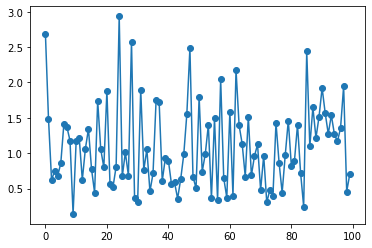

Some Train Test space visualizations


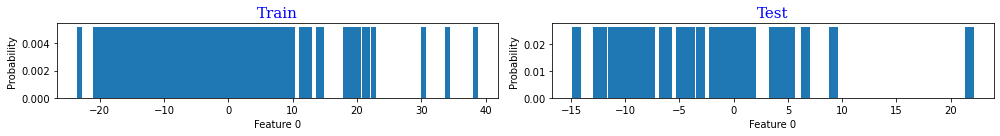

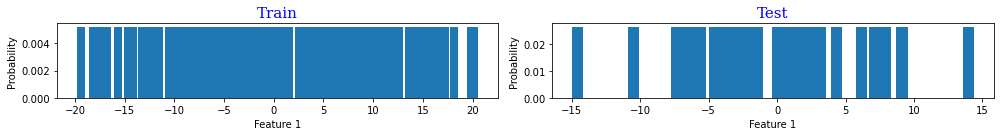

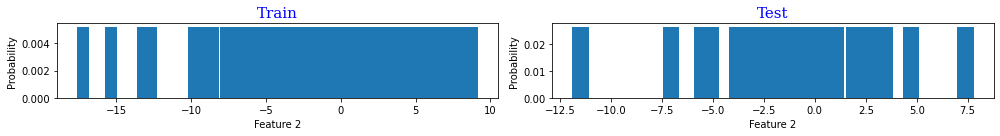

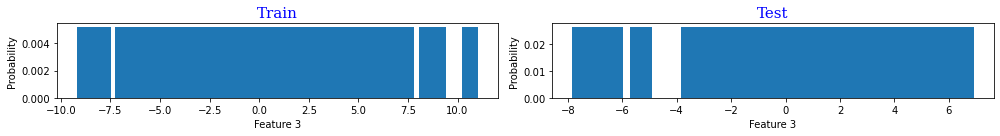

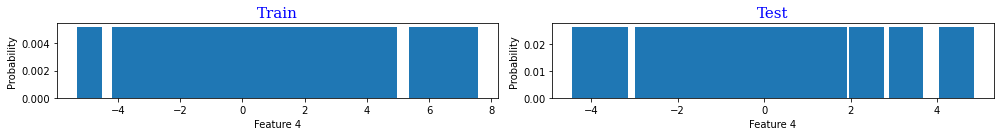

In [174]:
best_mlsubset_forp7 = []
best_mlsubset_forp7.extend(best_shapes_pca_p8)
best_mlsubset_forp7.extend(best_shapes_pca_p24)
best_mlsubset_forp7.extend(best_shapes_pca_p34)
best_mlsubset_forp7.extend(best_shapes_pca_p46)
best_mlsubset_forp7.extend(best_shapes_pca_p52)

train_shapes = best_mlsubset_forp7
test_set = [196, 35, 198, 171, 140, 141, 40, 203, 204, 230, 206, 207, 45, 208, 115, 149, 236, 183, 238, 239, 87, 186, 155, 123, 156, 92, 58, 159, 60, 245, 97, 63, 163, 65, 66, 100, 68, 167]
test_shapes = get_shape_reps(shapes_reps_pca_p7, test_set)

num_bins = 10
dimensions = 100

feature_kld = []
for i in range(dimensions):
    feature_kld.append(get_kld(train_shapes, test_shapes, i, num_bins))
print("Average KL Divergence:", np.average(feature_kld))

plt.plot(feature_kld)
plt.scatter(range(len(feature_kld)), feature_kld)
plt.show()

print("Some Train Test space visualizations")

get_distribution_plots(All, 5)

Average KL Divergence: 1.142472394416269


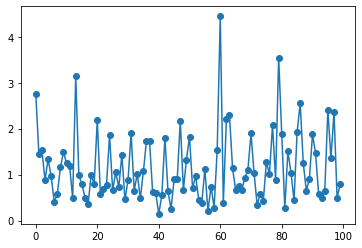

In [175]:
best_mlsubset_forp7_k3 = []
best_mlsubset_forp7_k3.extend(best_shapes_pca_p8)
best_mlsubset_forp7_k3.extend(best_shapes_pca_p24)
best_mlsubset_forp7_k3.extend(best_shapes_pca_p34)
best_mlsubset_forp7_k3.extend(best_shapes_pca_p46)
best_mlsubset_forp7_k3.extend(best_shapes_pca_p52)

train_shapes = best_mlsubset_forp7_k3
test_set = [221, 35, 223, 171, 225, 201, 142, 228, 204, 205, 177, 207, 45, 233, 115, 116, 236, 237, 238, 239, 87, 186, 155, 123, 243, 57, 58, 159, 191, 245, 97, 63, 163, 65, 66, 100, 68, 167]
test_shapes = get_shape_reps(shapes_reps_pca_p7, test_set)

num_bins = 10
dimensions = 100

feature_kld = []
for i in range(dimensions):
    feature_kld.append(get_kld(train_shapes, test_shapes, i, num_bins))
print("Average KL Divergence:", np.average(feature_kld))

plt.plot(feature_kld)
plt.scatter(range(len(feature_kld)), feature_kld)
plt.show()

Average KL Divergence: 0.5299290768153596


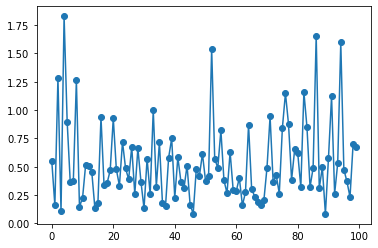

In [176]:
best_mlsubset_forp8 = []
best_mlsubset_forp8.extend(best_shapes_pca_p7)
best_mlsubset_forp8.extend(best_shapes_pca_p24)
best_mlsubset_forp8.extend(best_shapes_pca_p34)
best_mlsubset_forp8.extend(best_shapes_pca_p46)
best_mlsubset_forp8.extend(best_shapes_pca_p52)

train_shapes = best_mlsubset_forp8
test_set = [70, 71, 107, 143, 232, 233, 75, 76, 112, 113, 43, 9, 45, 46, 47, 84, 49, 120, 51, 186, 89, 124, 20, 244, 58, 128, 161, 61, 131, 98, 248, 224, 65, 225, 168, 32, 33]
test_shapes = get_shape_reps(shapes_reps_pca_p8, test_set)

num_bins = 10
dimensions = 100

feature_kld = []
for i in range(dimensions):
    feature_kld.append(get_kld(train_shapes, test_shapes, i, num_bins))
print("Average KL Divergence:", np.average(feature_kld))

plt.plot(feature_kld)
plt.scatter(range(len(feature_kld)), feature_kld)
plt.show()

Average KL Divergence: 0.7177046460555728


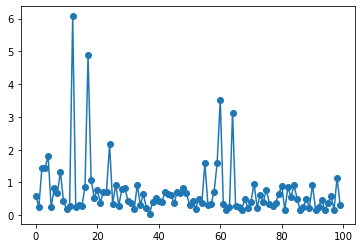

In [177]:
best_mlsubset_forp8_k3 = []
best_mlsubset_forp8_k3.extend(best_shapes_pca_p7)
best_mlsubset_forp8_k3.extend(best_shapes_pca_p24)
best_mlsubset_forp8_k3.extend(best_shapes_pca_p34)
best_mlsubset_forp8_k3.extend(best_shapes_pca_p46)
best_mlsubset_forp8_k3.extend(best_shapes_pca_p52)

train_shapes = best_mlsubset_forp8_k3
test_set = [70, 141, 107, 175, 232, 233, 39, 76, 112, 236, 43, 9, 45, 82, 47, 84, 14, 120, 51, 186, 53, 124, 20, 244, 159, 128, 161, 61, 131, 132, 248, 249, 65, 167, 168, 68, 33]
test_shapes = get_shape_reps(shapes_reps_pca_p8, test_set)

num_bins = 10
dimensions = 100

feature_kld = []
for i in range(dimensions):
    feature_kld.append(get_kld(train_shapes, test_shapes, i, num_bins))
print("Average KL Divergence:", np.average(feature_kld))

plt.plot(feature_kld)
plt.scatter(range(len(feature_kld)), feature_kld)
plt.show()